In [1]:
# Task 1 : Import dataset

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split

filepath = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv'

df = pd.read_csv(filepath, names=['age','gender','bmi','no_of_children','smoker','region','charges'])
df

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520
...,...,...,...,...,...,...,...
2767,47,1,45.320,1,0,4,8569.86180
2768,21,1,34.600,0,0,3,2020.17700
2769,19,2,26.030,1,1,1,16450.89470
2770,23,2,18.715,0,0,1,21595.38229


In [2]:
# Check for content with '?' 
(df=='?').sum()

age               4
gender            0
bmi               0
no_of_children    0
smoker            7
region            0
charges           0
dtype: int64

In [3]:
# replace all '?' with NaN
df.replace('?',np.nan, inplace=True)
(df=='?').sum()

age               0
gender            0
bmi               0
no_of_children    0
smoker            0
region            0
charges           0
dtype: int64

In [4]:
# check for null content
df.isna().sum()

age               4
gender            0
bmi               0
no_of_children    0
smoker            7
region            0
charges           0
dtype: int64

In [5]:
# alternate way to check for null count
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2768 non-null   str    
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2765 non-null   str    
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 151.7 KB


In [6]:
# Task 2 : Data Wrangling
# Use dataframe.info() to identify the columns that have some 'Null' (or NaN) information.
# Handle missing data:
    # For continuous attributes (e.g., age), replace missing values with the mean.
    # For categorical attributes (e.g., smoker), replace missing values with the most frequent value.
    # Update the data types of the respective columns.
    # Verify the update using df.info().

# Replace missing age value with its mean value
avg_age = df["age"].astype("float").mean(axis=0)
df["age"] = df["age"].replace(np.nan, avg_age)

# Replace missing smoker values with its most frequent value
freq_smoker = df["smoker"].value_counts().idxmax()
df['smoker'] = df['smoker'].replace(np.nan, freq_smoker)

# correct the data type
df[["age","smoker"]] = df[["age","smoker"]].astype("int64")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   int64  
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   int64  
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 151.7 KB


In [7]:
# Also note, that the charges column has values which are more than 2 decimal places long. Update the charges column such that all values 
# are rounded to nearest 2 decimal places. Verify conversion by printing the first 5 values of the updated dataframe.
df[['charges']] = np.round(df[['charges']],2)
df

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92
1,18,2,33.770,1,0,4,1725.55
2,28,2,33.000,3,0,4,4449.46
3,33,2,22.705,0,0,1,21984.47
4,32,2,28.880,0,0,1,3866.86
...,...,...,...,...,...,...,...
2767,47,1,45.320,1,0,4,8569.86
2768,21,1,34.600,0,0,3,2020.18
2769,19,2,26.030,1,1,1,16450.89
2770,23,2,18.715,0,0,1,21595.38


(0.0, 66902.85800000001)

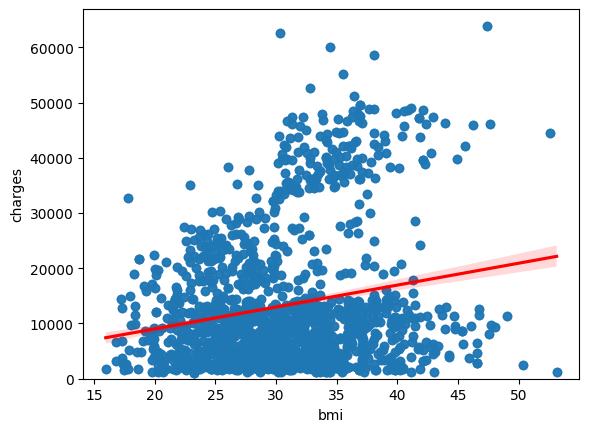

In [8]:
# Task 3 : Exploratory Data Analysis (EDA)
# Implement the regression plot for charges with respect to bmi. 

sns.regplot(x='bmi',y='charges', data=df, line_kws={'color':'red'})
plt.ylim(0,)


<Axes: xlabel='smoker', ylabel='charges'>

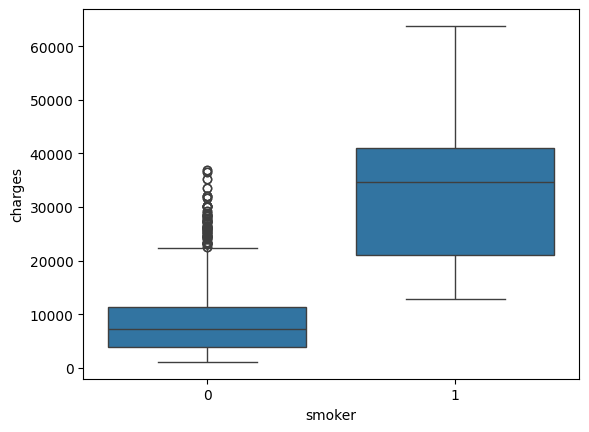

In [9]:
# Implement the box plot for charges with respect to smoker.
sns.boxplot(x='smoker', y='charges', data=df)

In [10]:
# Print the correlation matrix for the dataset
df.select_dtypes(include=['number']).corr()

,age,gender,bmi,no_of_children,smoker,region,charges
age,1.000000,-0.026046,0.113048,0.037574,-0.023286,-0.007167,0.298624
gender,-0.026046,1.000000,0.042924,0.016020,0.082326,0.022213,0.062837
bmi,0.113048,0.042924,1.000000,-0.001492,0.011489,0.271119,0.199846
no_of_children,0.037574,0.016020,-0.001492,1.000000,0.006362,-0.025717,0.066442
smoker,-0.023286,0.082326,0.011489,0.006362,1.000000,0.054077,0.788783
region,-0.007167,0.022213,0.271119,-0.025717,0.054077,1.000000,0.054058
charges,0.298624,0.062837,0.199846,0.066442,0.788783,0.054058,1.000000


In [11]:
# Task 4 : Model Development
# Fit a linear regression model that may be used to predict the charges value, just by using the smoker attribute of the dataset. Print the score of this model.
lm = LinearRegression()
lm.fit(df[['smoker']], df['charges'])
print(f"R^2 score: {lm.score(df[['smoker']],df['charges']) * 100:.2f} %")

R^2 score: 62.22 %


In [12]:
# Fit a linear regression model that may be used to predict the charges value, just by using all other attributes of the dataset. 
# Print the score of this model. You should see an improvement in the performance.
X = df[['age','gender','bmi','no_of_children','smoker','region']]
Y = df['charges']
lr = LinearRegression()
lr.fit(X,Y)
print(f"R^2 score: {lr.score(X,Y) * 100:.2f} %")

R^2 score: 75.04 %


In [13]:
# Create a training pipeline that uses StandardScaler(), PolynomialFeatures() and LinearRegression() to create a model that 
# can predict the charges value using all the other attributes of the dataset. There should be even further improvement in the performance.
Input = [('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]
pipe = Pipeline(Input)
X = X.astype(float)
pipe.fit(X,Y)
ypipe = pipe.predict(X)

r_square = r2_score(Y, ypipe) * 100
mse = mean_squared_error(Y, ypipe)
print(f"R^2 score = {r_square:.2f} %")
rmse = np.sqrt(mse)
print(f"On average, the model's predictions are off by about $ {rmse:.2f}")


R^2 score = 84.53 %
On average, the model's predictions are off by about $ 4779.32


In [17]:
# Task 5 : Model Refinement
# Split the data into training and testing subsets, assuming that 20% of the data will be reserved for testing.

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=1) 


In [21]:
# Initialize a Ridge regressor that used hyperparameter alpha=0.1. Fit the model using training data subset. Print the R^2 score for the testing data.
RigeModel = Ridge(alpha=0.1) 
RigeModel.fit(x_train, y_train)
test_score, train_score = RigeModel.score(x_test, y_test), RigeModel.score(x_train, y_train)
print(f"R^2 score = {test_score * 100:.2f} %")

# alternatively...
yhat = RigeModel.predict(x_test)
print(f"R^2 score = {r2_score(y_test,yhat) * 100:.2f} %")



R^2 score = 67.61 %
R^2 score = 67.61 %


In [22]:
# Apply polynomial transformation to the training parameters with degree=2. Use this transformed feature set to fit the same regression model, as above, 
# using the training subset. Print the R^2 score for the testing subset.

pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train) # include all features since none specified
x_test_pr  = pr.fit_transform( x_test)
RigeModel = Ridge(alpha=0.1) 
RigeModel.fit(x_train_pr, y_train)
yhat = RigeModel.predict(x_test_pr)
print(f"R^2 score = {r2_score(y_test,yhat) * 100:.2f} %")


R^2 score = 78.36 %
